<img src="../assets/header.gif" style="width:100%">
<hr style="color:#808080;">
<p align="center"><b>S H A G G Y&nbsp;&nbsp;&nbsp;—&nbsp;&nbsp;&nbsp;O P T I M I Z E R S</b></p>
<hr style="color:#808080;">

This notebook compares the optimizers of `shaggy`, **SOAP** and **HybridMA** (Muon for the weight matrices, AdamW for the rest), against the usual **AdamW**, on a small regression task: predicting the oxygen profile of an ocean column from its temperature profile.

In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from IPython.display import clear_output

from shaggy.loss import loss_reconstruction
from shaggy.optimizers import SOAP, HybridMA, safe_gradient_step

<hr style="color:#808080;">
<p align="center"><b>C O N F I G U R A T I O N</b></p>
<hr style="color:#808080;">

All the parameters that influence the notebook are grouped in the dictionaries below.

In [2]:
config = {
    "data": {
        "x": "data/x-dummy.pt",
        "mask": "data/m-dummy.pt",
        "n_val": 2_000,
        "seed": 0,
    },
    "model": {
        "hid_features": 128,
        "hid_layers": 2,
    },
    "train": {
        "lr": {"AdamW": 1e-3, "SOAP": 1e-3, "HybridMA": 1e-3},
        "weight_decay": 0.01,
        "steps": 2_000,
        "batch_size": 256,
    },
    "plot": {
        "refresh_every": 50,
    },
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<hr style="color:#808080;">
<p align="center"><b>D A T A S E T</b></p>
<hr style="color:#808080;">

Each sea pixel gives one ocean column: its 4 temperature levels (channels `0-3`) are the input and its 4 oxygen levels (channels `4-7`) are the target. Only pixels where every level is sea are kept, and a few columns are held out for validation.

In [3]:
x = torch.load(config["data"]["x"])        # (N, 8, Y, X)
mask = torch.load(config["data"]["mask"])  # (8, Y, X)

# One column per sea pixel and per sample, depth levels as features (N * sea pixels, 8)
sea = mask.bool().all(dim=0)
columns = x.movedim(1, -1)[:, sea].flatten(0, 1).to(device)
temperature, oxygen = columns[:, :4], columns[:, 4:]

# Random split of the columns into training and validation
generator = torch.Generator().manual_seed(config["data"]["seed"])
permutation = torch.randperm(len(columns), generator=generator)
val, train = permutation[: config["data"]["n_val"]], permutation[config["data"]["n_val"] :]

print(f"Columns | train: {len(train):,} | validation: {len(val):,}")

Columns | train: 225,408 | validation: 2,000


<hr style="color:#808080;">
<p align="center"><b>M O D E L</b></p>
<hr style="color:#808080;">

The model is a small multilayer perceptron (MLP). Each optimizer trains its own copy, and all copies start from the same weights so that the comparison is fair.

In [4]:
def build_mlp(hid_features: int, hid_layers: int) -> nn.Module:
    r"""Builds an MLP mapping a temperature profile (4) to an oxygen profile (4)."""
    layers = [nn.Linear(4, hid_features), nn.SiLU()]
    for _ in range(hid_layers):
        layers += [nn.Linear(hid_features, hid_features), nn.SiLU()]
    return nn.Sequential(*layers, nn.Linear(hid_features, 4))


models = {}
for name in config["train"]["lr"]:
    torch.manual_seed(config["data"]["seed"])
    models[name] = build_mlp(**config["model"]).to(device)

lr, weight_decay = config["train"]["lr"], config["train"]["weight_decay"]

optimizers = {
    "AdamW": torch.optim.AdamW(
        models["AdamW"].parameters(), lr["AdamW"], weight_decay=weight_decay
    ),
    "SOAP": SOAP(models["SOAP"].parameters(), lr["SOAP"], weight_decay=weight_decay),
    "HybridMA": HybridMA(models["HybridMA"], lr["HybridMA"], weight_decay=weight_decay),
}

<hr style="color:#808080;">
<p align="center"><b>T R A I N I N G</b></p>
<hr style="color:#808080;">

All models see the exact same batches and minimize the mean squared error (MSE). The training loss (left) and the validation loss (right) are refreshed live.

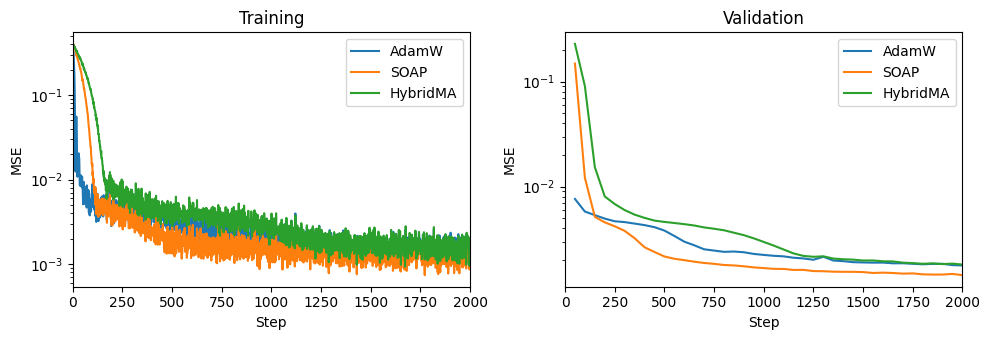

In [5]:
steps, batch_size = config["train"]["steps"], config["train"]["batch_size"]
refresh_every = config["plot"]["refresh_every"]

train_loss = {name: [] for name in models}
val_loss = {name: [] for name in models}
val_steps = []

for step in range(1, steps + 1):
    batch = train[torch.randint(len(train), (batch_size,))]

    for name, model in models.items():
        loss = loss_reconstruction(model(temperature[batch]), oxygen[batch])
        loss.backward()
        safe_gradient_step(optimizers[name])
        train_loss[name].append(loss.item())

    if step % refresh_every == 0 or step == steps:
        with torch.no_grad():
            for name, model in models.items():
                prediction = model(temperature[val])
                val_loss[name].append(loss_reconstruction(prediction, oxygen[val]).item())
        val_steps.append(step)

        clear_output(wait=True)
        fig, (ax_train, ax_val) = plt.subplots(1, 2, figsize=(10, 3.5))
        for name in models:
            ax_train.plot(range(1, step + 1), train_loss[name], label=name)
            ax_val.plot(val_steps, val_loss[name], label=name)
        for ax, title in [(ax_train, "Training"), (ax_val, "Validation")]:
            ax.set(title=title, xlabel="Step", ylabel="MSE", xlim=(0, steps), yscale="log")
            ax.legend()
        plt.tight_layout()
        plt.show()

<hr style="color:#808080;">
<p align="center"><b>R E S U L T S</b></p>
<hr style="color:#808080;">

The final validation error of each optimizer, as a root mean squared error (RMSE, lower is better).

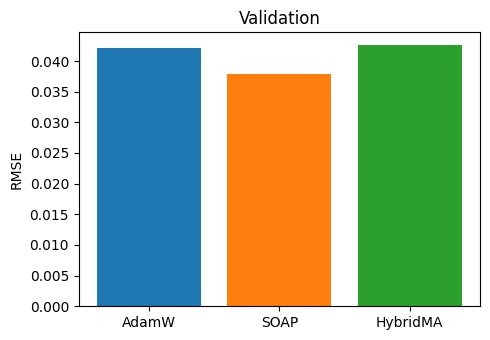

In [6]:
rmse = {name: losses[-1] ** 0.5 for name, losses in val_loss.items()}

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(rmse.keys(), rmse.values(), color=[f"C{i}" for i in range(len(rmse))])
ax.set(title="Validation", ylabel="RMSE")
plt.tight_layout()
plt.show()